<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_LAB2/EXPERIENCIA_4%20/RA1_Lab_N%C2%B02_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 2 — Aprendizaje en Redes Neuronales Artificiales

## Experiencia 4: Segmentacion de grietas en estructuras de hormigon — U-Net


**Dataset:** Imagenes RGB de superficie de hormigon con mascaras binarias de grietas  
**Framework:** TensorFlow / Keras 3  
**Grupo:** G8  
**Fecha:** 05/2026

---

La tarea es segmentacion semantica binaria: para cada pixel de la imagen, decidir si corresponde a una grieta o a superficie sana. La salida es una imagen de las mismas dimensiones que la entrada, con una prediccion por pixel. Con imagenes de 256x256, cada inferencia produce 65.536 predicciones simultaneas.

El problema combina dos dificultades: las grietas son estructuras muy delgadas (1 a 3 pixeles de ancho) y ocupan una fraccion pequeña del area total. Esto hace que las metricas y funciones de perdida estandar resulten inadecuadas, como se demuestra a lo largo de este notebook.



---



## 0. Configuracion del entorno

In [ ]:
import os
if not os.path.exists('cracks'):
    import subprocess
    subprocess.run(['wget','-q','-c','--no-check-certificate',
        'https://drive.google.com/uc?export=download&id=1MMQXhR3-Q0xSFskI7lC8mEhywkzTlhVc&confirm=t',
        '-O','concreto_agrietado_segmentacion.zip'])
    subprocess.run(['unzip','-qq','concreto_agrietado_segmentacion.zip'])
    print('Dataset descomprimido.')
else:
    print('Dataset ya disponible.')


Dataset descomprimido.


In [ ]:
import tensorflow as tf
import keras
print(f'TensorFlow: {tf.__version__}')
print(f'Keras:      {keras.__version__}')
assert int(keras.__version__.split('.')[0]) >= 3, 'Este notebook requiere Keras 3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re, cv2, os, glob, time, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from typing import List
from keras import layers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE   = 256
N_CHANNELS = 1
BATCH_SIZE = 8
MASK_THR   = 0.5

FIG_DIR = Path('figuras_informe')
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
})

def guardar(fig, nombre):
    fig.savefig(FIG_DIR / f'{nombre}.png')

print('Entorno configurado.')


TensorFlow: 2.20.0
Keras:      3.13.2
Entorno configurado.



---



## 1. Carga y estructura del dataset

In [ ]:
DATA_ROOT = Path('/content/')
IMG_DIR   = DATA_ROOT / 'cracks'
MASK_DIR  = DATA_ROOT / 'labels'

for d in [IMG_DIR, MASK_DIR]:
    if not d.exists():
        print(f'AVISO: {d} no encontrado')

img_paths      = sorted(glob.glob(str(IMG_DIR / '*.jpg')) + glob.glob(str(IMG_DIR / '*.png')))
mask_paths_all = sorted(glob.glob(str(MASK_DIR / '*')))

stems_img  = {Path(p).stem for p in img_paths}
stems_mask = {Path(p).stem for p in mask_paths_all}
sin_mascara = stems_img - stems_mask
sin_imagen  = stems_mask - stems_img

print(f'Imagenes encontradas:  {len(img_paths)}')
print(f'Mascaras encontradas:  {len(mask_paths_all)}')
print(f'Imagenes sin mascara:  {len(sin_mascara)}')
print(f'Mascaras sin imagen:   {len(sin_imagen)}')


Imagenes encontradas:  410
Mascaras encontradas:  410
Imagenes sin mascara:  0
Mascaras sin imagen:   0



---



## 2. Exploracion y auditoria del dataset

Antes de diseñar ninguna arquitectura, se audita la calidad del dataset. El etiquetado fue realizado por un equipo externo; la calidad de las mascaras condiciona el techo de desempeno del modelo: entrenar sobre etiquetas incorrectas produce un modelo que aprende el error del anotador, no la geometria de la grieta.

Se examinan cuatro aspectos:
1. Distribucion del desbalance de clases (fraccion de pixeles de grieta por imagen).
2. Alineamiento visual imagen-mascara.
3. Consistencia del color utilizado para la clase grieta.
4. Casos anomalos: mascaras vacias, mascaras que cubren toda la imagen.


In [ ]:
def estadisticas_dataset(img_paths, mask_dir):
    tamanios, crack_fracs, colores_grieta = [], [], []
    for p in img_paths:
        stem = Path(p).stem
        img  = cv2.imread(p)
        if img is not None:
            tamanios.append(img.shape[:2])
        mp = Path(mask_dir) / (stem + '.png')
        if mp.exists():
            m = cv2.imread(str(mp))
            if m is not None:
                mg = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)
                crack_fracs.append((mg > 100).mean())
                no_neg = m.reshape(-1,3)
                no_neg = no_neg[no_neg.max(axis=1) > 50]
                if len(no_neg):
                    colores_grieta.append(no_neg.mean(axis=0))
            else:
                crack_fracs.append(0.0)
        else:
            crack_fracs.append(0.0)
    return np.array(tamanios), np.array(crack_fracs), np.array(colores_grieta) if colores_grieta else np.zeros((1,3))

if len(img_paths) > 0:
    tamanios, crack_fracs, colores_grieta = estadisticas_dataset(img_paths, MASK_DIR)

    print('=== Estadisticas del dataset ===')
    print(f'  Total imagenes:            {len(img_paths)}')
    print(f'  Tamanos H: [{tamanios[:,0].min()} - {tamanios[:,0].max()}]  '
          f'W: [{tamanios[:,1].min()} - {tamanios[:,1].max()}]')
    print(f'  Fraccion grieta media:     {crack_fracs.mean()*100:.2f}%')
    print(f'  P10={np.percentile(crack_fracs,10)*100:.1f}%  '
          f'P50={np.percentile(crack_fracs,50)*100:.1f}%  '
          f'P90={np.percentile(crack_fracs,90)*100:.1f}%')
    print(f'  Imagenes con <0.1% grieta: {(crack_fracs<0.001).sum()}')
    print(f'  Imagenes con >50% grieta:  {(crack_fracs>0.5).sum()}')
    print()
    print('=== Auditoria de color en mascaras ===')
    print(f'  Color medio de grieta (B,G,R): '
          f'({colores_grieta[:,0].mean():.0f}, {colores_grieta[:,1].mean():.0f}, {colores_grieta[:,2].mean():.0f})')
    print(f'  Desv. std:  B={colores_grieta[:,0].std():.1f}  G={colores_grieta[:,1].std():.1f}  R={colores_grieta[:,2].std():.1f}')
    if colores_grieta.std() > 30:
        print('  ATENCION: alta variabilidad -> posible inconsistencia entre anotadores')
    else:
        print('  Color consistente entre mascaras.')


=== Estadisticas del dataset ===
  Total imagenes:            410
  Tamanos H: [227 - 227]  W: [227 - 227]
  Fraccion grieta media:     9.91%
  P10=4.2%  P50=8.9%  P90=16.3%
  Imagenes con <0.1% grieta: 0
  Imagenes con >50% grieta:  0

=== Auditoria de color en mascaras ===
  Color medio de grieta (B,G,R): (64, 128, 64)
  Desv. std:  B=0.0  G=0.0  R=0.0
  ATENCION: alta variabilidad -> posible inconsistencia entre anotadores


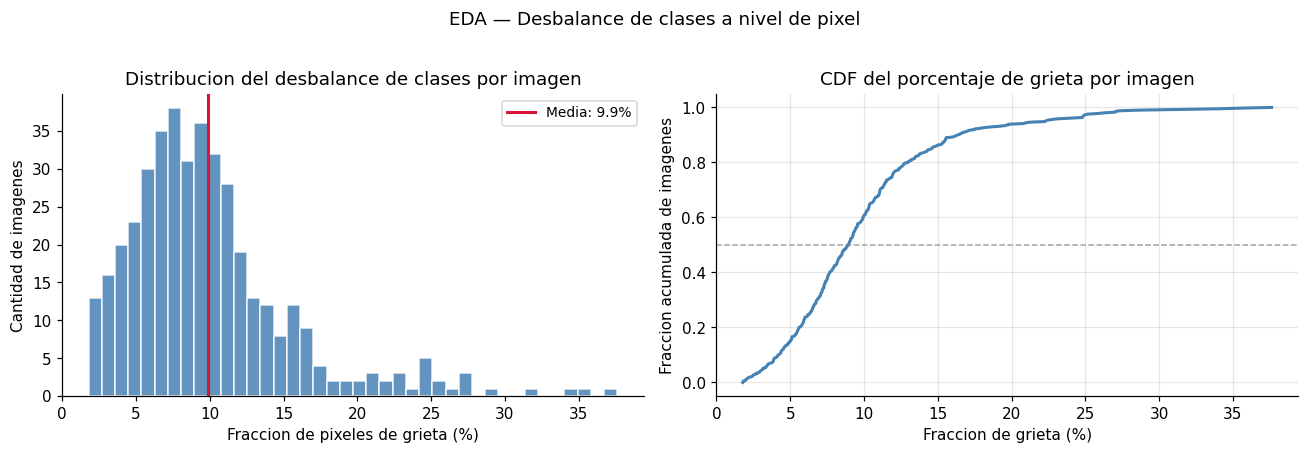

In [ ]:
if len(img_paths) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(crack_fracs * 100, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].axvline(crack_fracs.mean()*100, color='crimson', lw=2,
                    label=f'Media: {crack_fracs.mean()*100:.1f}%')
    axes[0].set_xlabel('Fraccion de pixeles de grieta (%)')
    axes[0].set_ylabel('Cantidad de imagenes')
    axes[0].set_title('Distribucion del desbalance de clases por imagen')
    axes[0].legend(fontsize=9)

    sorted_cf = np.sort(crack_fracs) * 100
    axes[1].plot(sorted_cf, np.linspace(0, 1, len(sorted_cf)), 'steelblue', lw=2)
    axes[1].axhline(0.5, color='gray', lw=1, linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Fraccion de grieta (%)')
    axes[1].set_ylabel('Fraccion acumulada de imagenes')
    axes[1].set_title('CDF del porcentaje de grieta por imagen')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('EDA — Desbalance de clases a nivel de pixel', fontsize=12, y=1.02)
    plt.tight_layout()
    guardar(fig, '01_eda_desbalance')
    plt.show()


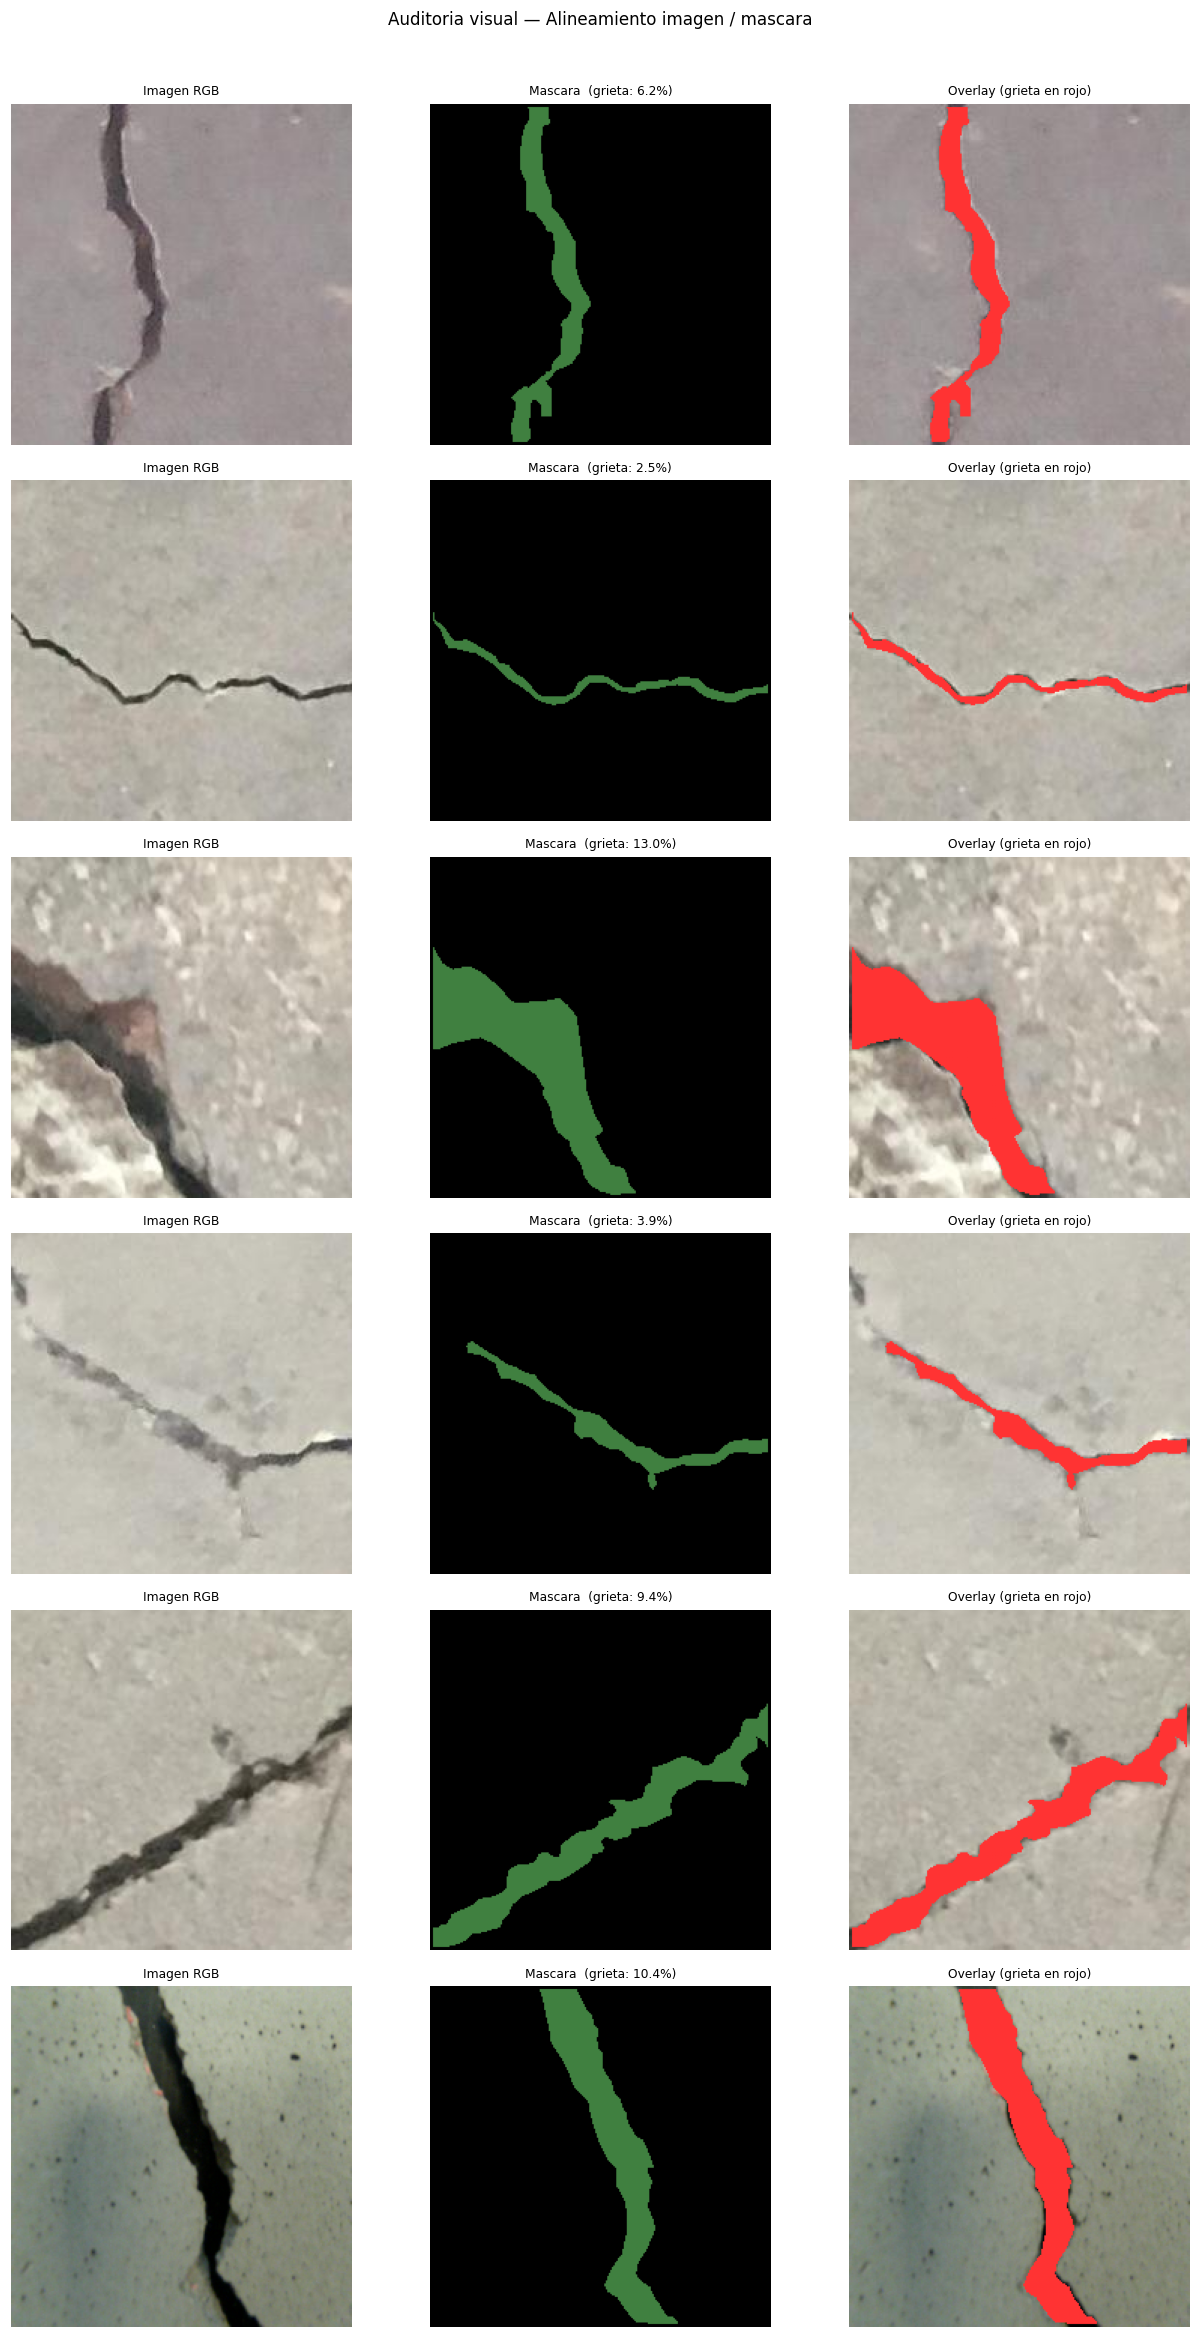

In [ ]:
if len(img_paths) > 0:
    n_show = min(6, len(img_paths))
    indices = np.linspace(0, len(img_paths)-1, n_show, dtype=int)

    fig, axes = plt.subplots(n_show, 3, figsize=(12, 3.5*n_show))

    for row, idx in enumerate(indices):
        p    = img_paths[idx]
        stem = Path(p).stem
        img_bgr = cv2.imread(p)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        mp = MASK_DIR / (stem + '.png')
        mask_color = cv2.imread(str(mp)) if mp.exists() else None
        mask_gray  = cv2.cvtColor(mask_color, cv2.COLOR_BGR2GRAY) if mask_color is not None else np.zeros(img_rgb.shape[:2])
        overlay = img_rgb.copy().astype(np.float32) / 255.0
        grieta_px = mask_gray > 100
        overlay[grieta_px, 0] = 1.0
        overlay[grieta_px, 1] = 0.2
        overlay[grieta_px, 2] = 0.2
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f'Imagen RGB', fontsize=8)
        axes[row, 1].imshow(mask_color[:,:,::-1] if mask_color is not None else mask_gray,
                            cmap=None if mask_color is not None else 'gray')
        axes[row, 1].set_title(f'Mascara  (grieta: {grieta_px.mean()*100:.1f}%)', fontsize=8)
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title('Overlay (grieta en rojo)', fontsize=8)
        for ax in axes[row]: ax.axis('off')

    plt.suptitle('Auditoria visual — Alineamiento imagen / mascara', fontsize=11, y=1.01)
    plt.tight_layout()
    guardar(fig, '02_auditoria_visual')
    plt.show()


In [ ]:
if len(img_paths) > 0:
    print('=== RESUMEN AUDITORIA DE ETIQUETAS ===')
    print()
    n_vacias = (crack_fracs < 0.001).sum()
    print(f'1. Pares imagen-mascara completos: {len(img_paths)}')
    print(f'2. Imagenes con mascara < 0.1% grieta: {n_vacias} ({n_vacias/len(crack_fracs)*100:.1f}%)')
    print(f'   -> Pueden ser superficies sanas correctamente etiquetadas')
    print(f'   -> O etiquetado omitido. Revisar manualmente este subconjunto.')
    print()
    print('3. Estrategia de binarizacion de mascaras:')
    print('   Umbral > 100 en escala de grises absorbe variaciones de color')
    print('   de distintos anotadores sin perder la senal de grieta.')
    print()
    print('4. Imagenes con mascara vacia mantenidas como ejemplos negativos validos.')


=== RESUMEN AUDITORIA DE ETIQUETAS ===

1. Pares imagen-mascara completos: 410
2. Imagenes con mascara < 0.1% grieta: 0 (0.0%)
   -> Pueden ser superficies sanas correctamente etiquetadas
   -> O etiquetado omitido. Revisar manualmente este subconjunto.

3. Estrategia de binarizacion de mascaras:
   Umbral > 100 en escala de grises absorbe variaciones de color
   de distintos anotadores sin perder la senal de grieta.

4. Imagenes con mascara vacia mantenidas como ejemplos negativos validos.



---



## 3. Preprocesamiento

### 3.1 Grayscale vs. RGB

Las grietas se definen por contraste de intensidad, textura y morfologia. El color no es una señal discriminante: la misma grieta puede ser oscura, gris o blanquecina segun la iluminacion, la humedad o la camara. Trabajar en escala de grises reduce el volumen de datos por imagen en un factor de 3 sin perdida de informacion relevante, acelera el entrenamiento y mejora la generalizacion a condiciones de captura distintas.

### 3.2 Resolucion y compatibilidad con U-Net

Con profundidad 4, la U-Net aplica 4 operaciones de maxpooling de 2x2: `256 -> 128 -> 64 -> 32 -> 16`. La entrada debe ser multiplo de 2^depth (= 16) para que las dimensiones del encoder y el decoder se alineen exactamente en las skip connections. 256x256 es el estandar mas difundido en la literatura.

### 3.3 Interpolacion correcta para mascaras

Al redimensionar, las imagenes usan `INTER_AREA` (promedia pixeles, correcto para reducir). Las mascaras usan `INTER_NEAREST` obligatoriamente: la interpolacion bilineal crea valores intermedios entre 0 y 1 que rompen la binaridad de la etiqueta.


Varianza por canal:
  Canal R: 250.4
  Canal G: 261.9
  Canal B: 247.3
  Grayscale:  255.8


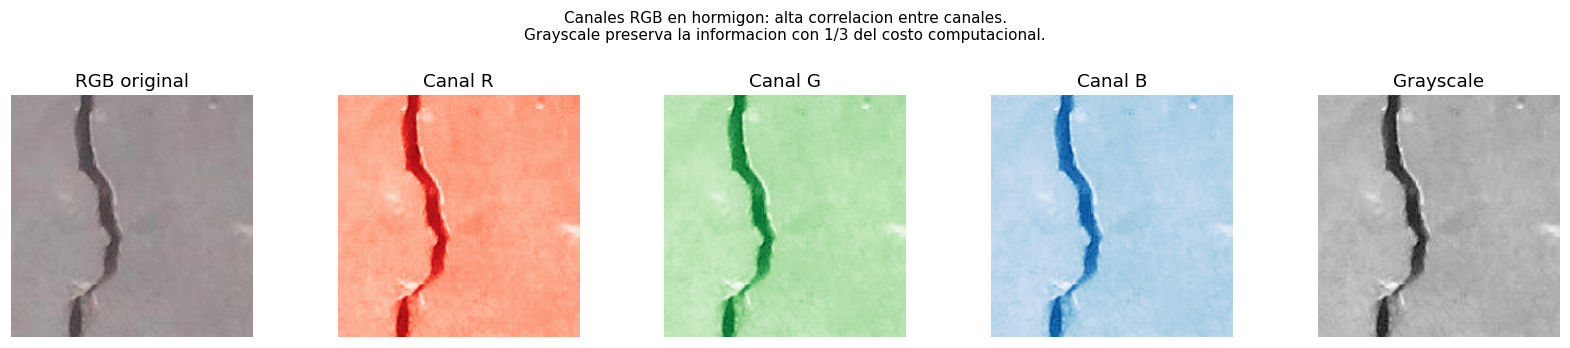

In [ ]:
if len(img_paths) > 0:
    img_demo = cv2.imread(img_paths[0])
    img_rgb  = cv2.cvtColor(img_demo, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_demo, cv2.COLOR_BGR2GRAY)

    print('Varianza por canal:')
    for i, name in enumerate(['R', 'G', 'B']):
        print(f'  Canal {name}: {img_rgb[:,:,i].var():.1f}')
    print(f'  Grayscale:  {img_gray.var():.1f}')

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    axes[0].imshow(img_rgb);                         axes[0].set_title('RGB original')
    axes[1].imshow(img_rgb[:,:,0], cmap='Reds_r');   axes[1].set_title('Canal R')
    axes[2].imshow(img_rgb[:,:,1], cmap='Greens_r'); axes[2].set_title('Canal G')
    axes[3].imshow(img_rgb[:,:,2], cmap='Blues_r');  axes[3].set_title('Canal B')
    axes[4].imshow(img_gray, cmap='gray');           axes[4].set_title('Grayscale')
    for ax in axes: ax.axis('off')
    plt.suptitle('Canales RGB en hormigon: alta correlacion entre canales.\n'
                 'Grayscale preserva la informacion con 1/3 del costo computacional.', fontsize=10, y=1.04)
    plt.tight_layout()
    guardar(fig, '03_rgb_vs_gray')
    plt.show()


In [ ]:
def cargar_imagen(path, size=IMG_SIZE, grayscale=True):
    img = cv2.imread(path)
    if img is None: raise ValueError(f'No se pudo leer: {path}')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if grayscale else cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    if grayscale: img = np.expand_dims(img, axis=-1)
    return img

def cargar_mascara(path, size=IMG_SIZE):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if mask is None: mask = np.zeros((size, size), dtype=np.uint8)
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    return np.expand_dims((mask > 100).astype(np.float32), axis=-1)

print('Funciones de carga definidas.')


Funciones de carga definidas.



---



## 4. Division del dataset y pipeline tf.data

Division 70/15/15 para train/val/test. El pipeline tf.data carga los datos en batch sobre disco sin mantener todo el dataset en memoria, lo que es relevante dentro de los 12 GB de RAM disponibles en Colab.

El data augmentation para segmentacion tiene una restriccion critica: cualquier transformacion geometrica aplicada a la imagen debe aplicarse identicamente a la mascara. Los cambios de brillo y contraste se aplican solo a la imagen (la mascara es binaria, no tiene intensidad).


In [ ]:
def construir_dataset(img_paths, mask_dir, size=IMG_SIZE, batch_size=BATCH_SIZE,
                       shuffle=True, augment=False, seed=SEED):
    img_list  = tf.constant(img_paths)
    stem_list = [Path(p).stem for p in img_paths]
    mask_list = tf.constant([str(Path(mask_dir) / (s + '.png')) for s in stem_list])

    def _load_pair(img_path, mask_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.rgb_to_grayscale(img)
        img = tf.image.resize(img, [size, size], method='area')
        img = tf.cast(img, tf.float32) / 255.0
        mask_raw = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask_raw, channels=1)
        mask = tf.image.resize(mask, [size, size], method='nearest')
        mask = tf.cast(mask > 100, tf.float32)
        return img, mask

    def _augment(img, mask):
        # Flip horizontal — sincronizado imagen y mascara
        if tf.random.uniform(()) > 0.5:
            img  = tf.image.flip_left_right(img)
            mask = tf.image.flip_left_right(mask)
        # Flip vertical
        if tf.random.uniform(()) > 0.5:
            img  = tf.image.flip_up_down(img)
            mask = tf.image.flip_up_down(mask)
        # Rotacion 90 grados (multiplos) — sincronizado
        k = tf.random.uniform((), 0, 4, dtype=tf.int32)
        img  = tf.image.rot90(img,  k=k)
        mask = tf.image.rot90(mask, k=k)
        # Brillo y contraste SOLO en imagen
        img = tf.image.random_brightness(img, max_delta=0.15)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.clip_by_value(img, 0.0, 1.0)
        return img, mask

    ds = tf.data.Dataset.from_tensor_slices((img_list, mask_list))
    if shuffle: ds = ds.shuffle(buffer_size=len(img_paths), seed=seed)
    ds = ds.map(_load_pair, num_parallel_calls=tf.data.AUTOTUNE)
    if augment: ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

if len(img_paths) > 0:
    idx_all = list(range(len(img_paths)))
    idx_train, idx_test = train_test_split(idx_all, test_size=0.15, random_state=SEED)
    idx_train, idx_val  = train_test_split(idx_train, test_size=0.15, random_state=SEED)
    train_paths = [img_paths[i] for i in idx_train]
    val_paths   = [img_paths[i] for i in idx_val]
    test_paths  = [img_paths[i] for i in idx_test]
    ds_train = construir_dataset(train_paths, str(MASK_DIR), augment=True,  shuffle=True)
    ds_val   = construir_dataset(val_paths,   str(MASK_DIR), augment=False, shuffle=False)
    ds_test  = construir_dataset(test_paths,  str(MASK_DIR), augment=False, shuffle=False)
    print(f'Train: {len(train_paths)}  Val: {len(val_paths)}  Test: {len(test_paths)}')
    print(f'Batches por epoca (train): {len(ds_train)}')
else:
    print('Sin imagenes cargadas.')


Train: 295  Val: 53  Test: 62
Batches por epoca (train): 37



---



## 5. Metricas de evaluacion

El accuracy de pixeles resulta engañoso con desbalance de clases. Con 5-15% de pixeles de grieta, un modelo que predice uniformemente 'fondo' obtiene entre 85% y 95% de accuracy sin detectar ninguna grieta. Las metricas adecuadas para segmentacion binaria desbalanceada son:

- **IoU (Intersection over Union)**: TP / (TP + FP + FN). Penaliza tanto falsos positivos como falsos negativos. Estandar en segmentacion semantica. Valor minimo de referencia para produccion: IoU > 0.5.
- **Dice Coefficient**: 2TP / (2TP + FP + FN), equivalente al F1-score por pixel. Mas sensible que IoU a regiones pequeñas. Siempre Dice >= IoU.
- **Accuracy de pixeles**: se reporta como referencia para ilustrar su inadecuacion.


In [ ]:
class DiceCoefficient(keras.metrics.Metric):
    def __init__(self, threshold=0.5, smooth=1e-6, name='dice', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold; self.smooth = smooth
        self.dice_sum  = self.add_weight(name='dice_sum', initializer='zeros')
        self.count     = self.add_weight(name='count',    initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin   = tf.cast(y_pred > self.threshold, tf.float32)
        y_true       = tf.cast(y_true, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred_bin, axis=[1,2,3])
        denom        = tf.reduce_sum(y_true + y_pred_bin, axis=[1,2,3])
        dice         = tf.reduce_mean((2*intersection + self.smooth)/(denom + self.smooth))
        self.dice_sum.assign_add(dice); self.count.assign_add(1.0)
    def result(self): return self.dice_sum / (self.count + 1e-10)
    def reset_state(self): self.dice_sum.assign(0.0); self.count.assign(0.0)

class IoUMetric(keras.metrics.Metric):
    def __init__(self, threshold=0.5, smooth=1e-6, name='iou', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold; self.smooth = smooth
        self.iou_sum   = self.add_weight(name='iou_sum', initializer='zeros')
        self.count     = self.add_weight(name='count',   initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin   = tf.cast(y_pred > self.threshold, tf.float32)
        y_true       = tf.cast(y_true, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred_bin, axis=[1,2,3])
        union        = tf.reduce_sum(y_true + y_pred_bin, axis=[1,2,3]) - intersection
        iou          = tf.reduce_mean((intersection + self.smooth)/(union + self.smooth))
        self.iou_sum.assign_add(iou); self.count.assign_add(1.0)
    def result(self): return self.iou_sum / (self.count + 1e-10)
    def reset_state(self): self.iou_sum.assign(0.0); self.count.assign(0.0)

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true       = tf.cast(y_true, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    denom        = tf.reduce_sum(y_true + y_pred,  axis=[1,2,3])
    return 1.0 - tf.reduce_mean((2*intersection + smooth) / (denom + smooth))

def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(keras.losses.binary_crossentropy(y_true, y_pred))
    return 0.5 * bce + 0.5 * dice_loss(y_true, y_pred)

def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0-1e-7)
    bce    = -y_true*tf.math.log(y_pred) - (1-y_true)*tf.math.log(1-y_pred)
    p_t    = y_true*y_pred + (1-y_true)*(1-y_pred)
    return tf.reduce_mean(alpha * tf.pow(1.0-p_t, gamma) * bce)

print('Metricas y funciones de perdida definidas.')


Metricas y funciones de perdida definidas.



---



## 6. Arquitectura U-Net

La U-Net (Ronneberger et al., 2015) fue diseñada para segmentacion de imagenes biomedicas con datasets pequeños. Su contribucion central son las **skip connections**, que conectan capas del encoder con capas del decoder del mismo nivel de resolucion.

**Encoder:** bloques de convolucion seguidos de maxpooling. Captura contexto semantico (donde hay grietas) pero pierde precision espacial.

**Cuello de botella:** representacion comprimida de mayor profundidad semantica.

**Decoder:** upsampling progresivo hacia la resolucion original.

**Skip connections:** concatenan feature maps del encoder con los del decoder al mismo nivel. Permiten al decoder recuperar la ubicacion exacta de bordes perdidos durante el downsampling. Para grietas de 1-3 pixeles de ancho, esta informacion es critica.


In [ ]:
def bloque_conv(x, filters, kernel_size=3, use_bn=True, dropout=0.0,
                n_convs=2, name_prefix=''):
    for k in range(n_convs):
        x = layers.Conv2D(filters, kernel_size, padding='same',
                          kernel_initializer='he_normal',
                          name=f'{name_prefix}_c{k}')(x)
        if use_bn:
            x = layers.BatchNormalization(name=f'{name_prefix}_bn{k}')(x)
        x = layers.Activation('relu', name=f'{name_prefix}_r{k}')(x)
    if dropout > 0:
        x = layers.SpatialDropout2D(dropout, name=f'{name_prefix}_drop')(x)
    return x

def unet(input_shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS),
         filters_base=32, depth=4, use_bn=True, dropout=0.1,
         use_skip=True, n_convs_per_block=2, nombre='unet'):
    inputs = keras.Input(shape=input_shape, name='input')
    x, skips = inputs, []
    # ENCODER
    for lvl in range(depth):
        f = filters_base * (2 ** lvl)
        x = bloque_conv(x, f, use_bn=use_bn, dropout=dropout,
                        n_convs=n_convs_per_block, name_prefix=f'enc{lvl}')
        skips.append(x)
        x = layers.MaxPooling2D(2, name=f'pool{lvl}')(x)
    # CUELLO DE BOTELLA
    f_bot = filters_base * (2 ** depth)
    x     = bloque_conv(x, f_bot, use_bn=use_bn, dropout=dropout,
                        n_convs=n_convs_per_block, name_prefix='bot')
    # DECODER
    for lvl in reversed(range(depth)):
        f = filters_base * (2 ** lvl)
        x = layers.Conv2DTranspose(f, 2, strides=2, padding='same', name=f'up{lvl}')(x)
        if use_skip:
            x = layers.Concatenate(name=f'skip{lvl}')([x, skips[lvl]])
        x = bloque_conv(x, f, use_bn=use_bn, dropout=dropout,
                        n_convs=n_convs_per_block, name_prefix=f'dec{lvl}')
    # SALIDA
    outputs = layers.Conv2D(1, 1, activation='sigmoid', name='output')(x)
    return keras.Model(inputs, outputs, name=nombre)

m_test = unet(filters_base=16, depth=4, nombre='test')
print(f'U-Net (16 base, depth=4): {m_test.count_params():,} parametros')
del m_test


U-Net (16 base, depth=4): 1,946,705 parametros



---



## 7. Experimento: skip connections vs. encoder-decoder puro

Se comparan empiricamente dos variantes: U-Net con skip connections y el mismo encoder-decoder sin ellas. La hipotesis es que sin skip connections el decoder no puede recuperar la ubicacion exacta de grietas delgadas porque esa informacion se disipa durante el downsampling y no hay camino para recuperarla desde el cuello de botella.


In [ ]:
def compilar_y_entrenar(modelo, ds_train, ds_val, epochs=50,
                         loss_fn=None, lr=1e-3, nombre=''):
    if loss_fn is None: loss_fn = bce_dice_loss
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=[keras.metrics.BinaryAccuracy(name='acc'),
                 DiceCoefficient(name='dice'),
                 IoUMetric(name='iou')]
    )
    cb = [
        EarlyStopping(monitor='val_iou', patience=10, mode='max',
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_iou', factor=0.5, patience=5,
                          mode='max', min_lr=1e-6, verbose=0),
        ModelCheckpoint(f'{nombre}_best.weights.h5', monitor='val_iou',
                        mode='max', save_best_only=True,
                        save_weights_only=True, verbose=0),
    ]
    t0   = time.time()
    hist = modelo.fit(ds_train, validation_data=ds_val,
                       epochs=epochs, callbacks=cb, verbose=1)
    return hist, time.time() - t0

if len(img_paths) > 0:
    modelo_skip   = unet(filters_base=16, depth=4, use_skip=True,  nombre='skip')
    modelo_nosk   = unet(filters_base=16, depth=4, use_skip=False, nombre='nosk')
    print(f'Con skip:   {modelo_skip.count_params():,} parametros')
    print(f'Sin skip:   {modelo_nosk.count_params():,} parametros')
    print()
    tf.random.set_seed(SEED)
    hist_skip, t_sk = compilar_y_entrenar(modelo_skip, ds_train, ds_val, epochs=60, nombre='sk')
    tf.random.set_seed(SEED)
    hist_nosk, t_ns = compilar_y_entrenar(modelo_nosk, ds_train, ds_val, epochs=60, nombre='ns')
    print(f'Con skip:  val_IoU={max(hist_skip.history["val_iou"]):.4f}  ({t_sk:.0f}s)')
    print(f'Sin skip:  val_IoU={max(hist_nosk.history["val_iou"]):.4f}  ({t_ns:.0f}s)')


Con skip:   1,946,705 parametros
Sin skip:   1,750,865 parametros

Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 73s 896ms/step - acc: 0.9361 - dice: 0.6821 - iou: 0.5580 - loss: 0.4426 - val_acc: 0.1336 - val_dice: 0.1787 - val_iou: 0.1010 - val_loss: 2.6005 - learning_rate: 0.0010
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - acc: 0.9592 - dice: 0.7980 - iou: 0.6821 - loss: 0.3062 - val_acc: 0.1420 - val_dice: 0.1804 - val_iou: 0.1021 - val_loss: 6.1842 - learning_rate: 0.0010
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - acc: 0.9634 - dice: 0.8164 - iou: 0.7021 - loss: 0.2465 - val_acc: 0.2300 - val_dice: 0.2147 - val_iou: 0.1251 - val_loss: 12.7319 - learning_rate: 0.0010
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - acc: 0.9665 - dice: 0.8279 - iou: 0.7208 - loss: 0.2138 - val_acc: 0.9363 - val_dice: 0.6985 - val_iou: 0.5462 - val_loss: 0.3759 - learning_rate: 0.0010
Epoch 5/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - acc: 0.9684 - dice: 0.8341 - iou: 0.7261 - loss:

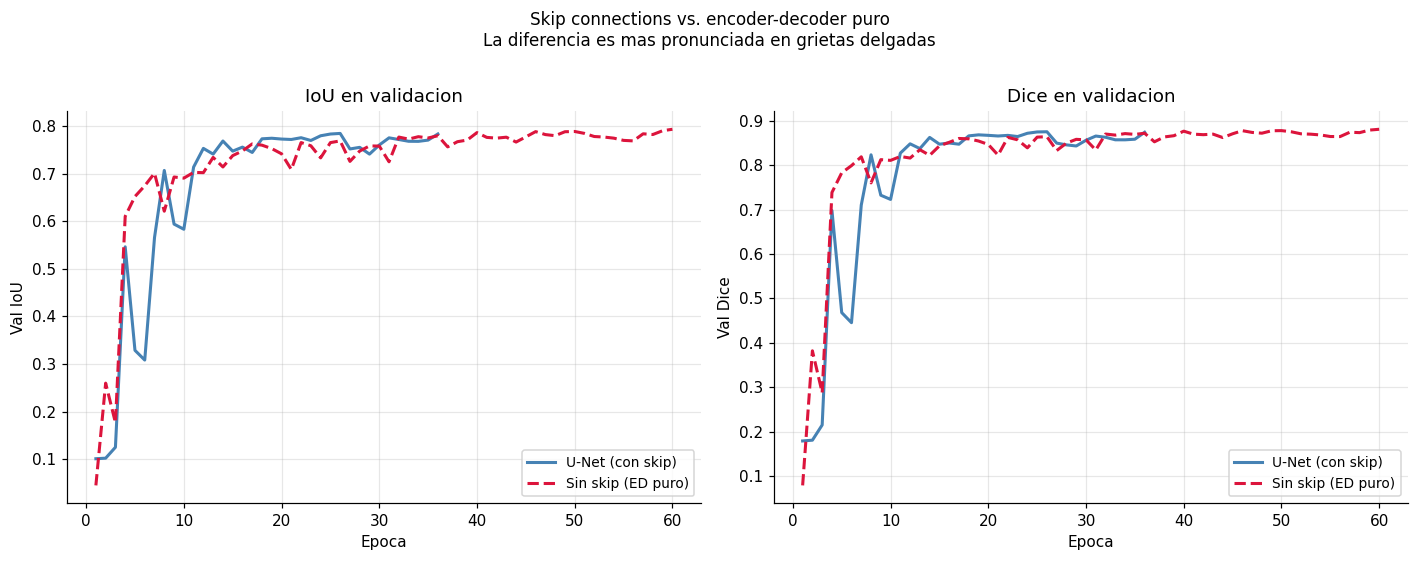

In [ ]:
if len(img_paths) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for hist, label, color, ls in [
        (hist_skip.history, 'U-Net (con skip)', 'steelblue', '-'),
        (hist_nosk.history, 'Sin skip (ED puro)', 'crimson', '--'),
    ]:
        ep = range(1, len(hist['val_iou']) + 1)
        axes[0].plot(ep, hist['val_iou'],  color=color, ls=ls, lw=2, label=label)
        axes[1].plot(ep, hist['val_dice'], color=color, ls=ls, lw=2, label=label)
    for ax, yl, tl in [
        (axes[0], 'Val IoU',  'IoU en validacion'),
        (axes[1], 'Val Dice', 'Dice en validacion'),
    ]:
        ax.set_xlabel('Epoca'); ax.set_ylabel(yl)
        ax.set_title(tl); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.suptitle('Skip connections vs. encoder-decoder puro\n'
                 'La diferencia es mas pronunciada en grietas delgadas', fontsize=11, y=1.01)
    plt.tight_layout()
    guardar(fig, '04_skip_vs_nosk')
    plt.show()



---



## 8. Experimento: capacidad de la red

Con un dataset pequeño (~500 imagenes), la capacidad del modelo es un factor critico. Una red con demasiados parametros puede memorizar el conjunto de entrenamiento sin aprender la estructura general de las grietas. Una red con muy pocos parametros puede carecer de expresividad para segmentar estructuras finas.

Se comparan tres configuraciones: Tiny, Small y Medium. La hipotesis es que Medium ofrece el balance optimo entre capacidad y regularizacion implicita del dataset pequeño.


In [ ]:
configs = {
    'Tiny  (4b, d=3)':  {'filters_base': 4,  'depth': 3},
    'Small (8b, d=4)':  {'filters_base': 8,  'depth': 4},
    'Medium(16b,d=4)':  {'filters_base': 16, 'depth': 4},
}

print(f"  {'Config':<20}  {'Params':>10}")
print('  ' + '-'*32)
for nombre, cfg in configs.items():
    m = unet(filters_base=cfg['filters_base'], depth=cfg['depth'], nombre='tmp')
    print(f"  {nombre:<20}  {m.count_params():>10,}")
    del m


  Config                    Params
  --------------------------------
  Tiny  (4b, d=3)           30,997
  Small (8b, d=4)          488,617
  Medium(16b,d=4)        1,946,705


In [ ]:
resultados_tam = {}

if len(img_paths) > 0:
    for nombre_cfg, cfg in configs.items():
        print(f'\nEntrenando {nombre_cfg}...')
        tf.random.set_seed(SEED)
        m = unet(filters_base=cfg['filters_base'], depth=cfg['depth'],
                 use_bn=True, dropout=0.1, use_skip=True,
                 nombre=re.sub(r'[^A-Za-z0-9_.\-]', '_', nombre_cfg[:12]))
        hist, elapsed = compilar_y_entrenar(
            m, ds_train, ds_val, epochs=60,
            nombre=re.sub(r'[^A-Za-z0-9_.\-]', '_', nombre_cfg[:12]))
        resultados_tam[nombre_cfg] = {
            'iou': max(hist.history['val_iou']),
            'dice': max(hist.history['val_dice']),
            'params': m.count_params(),
            'tiempo': elapsed,
            'history': hist.history,
        }
        print(f"  IoU={resultados_tam[nombre_cfg]['iou']:.4f}  "
              f"Dice={resultados_tam[nombre_cfg]['dice']:.4f}  "
              f"Params={m.count_params():,}  t={elapsed:.0f}s")

    print('\n' + '='*60)
    print('TABLA — Comparacion de capacidad de red')
    print('='*60)
    print(f"  {'Config':<22}  {'Params':>10}  {'IoU':>8}  {'Dice':>8}  {'t(s)':>6}")
    print('  ' + '-'*58)
    for n, r in resultados_tam.items():
        print(f"  {n:<22}  {r['params']:>10,}  {r['iou']:>8.4f}  {r['dice']:>8.4f}  {r['tiempo']:>6.0f}")



Entrenando Tiny  (4b, d=3)...
Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 38s 454ms/step - acc: 0.8589 - dice: 0.0629 - iou: 0.0330 - loss: 0.6648 - val_acc: 0.9018 - val_dice: 4.7493e-04 - val_iou: 2.3764e-04 - val_loss: 0.4779 - learning_rate: 0.0010
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - acc: 0.8859 - dice: 0.1374 - iou: 0.0842 - loss: 0.5826 - val_acc: 0.9019 - val_dice: 0.0020 - val_iou: 9.8759e-04 - val_loss: 0.5421 - learning_rate: 0.0010
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - acc: 0.9132 - dice: 0.5763 - iou: 0.4602 - loss: 0.5235 - val_acc: 0.9161 - val_dice: 0.2579 - val_iou: 0.1693 - val_loss: 0.5922 - learning_rate: 0.0010
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.9298 - dice: 0.6569 - iou: 0.5413 - loss: 0.4765 - val_acc: 0.9423 - val_dice: 0.6180 - val_iou: 0.4787 - val_loss: 0.5700 - learning_rate: 0.0010
Epoch 5/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - acc: 0.9462 - dice: 0.6892 - iou: 0.5777 - loss: 0.4283 - val_acc: 0.9560 

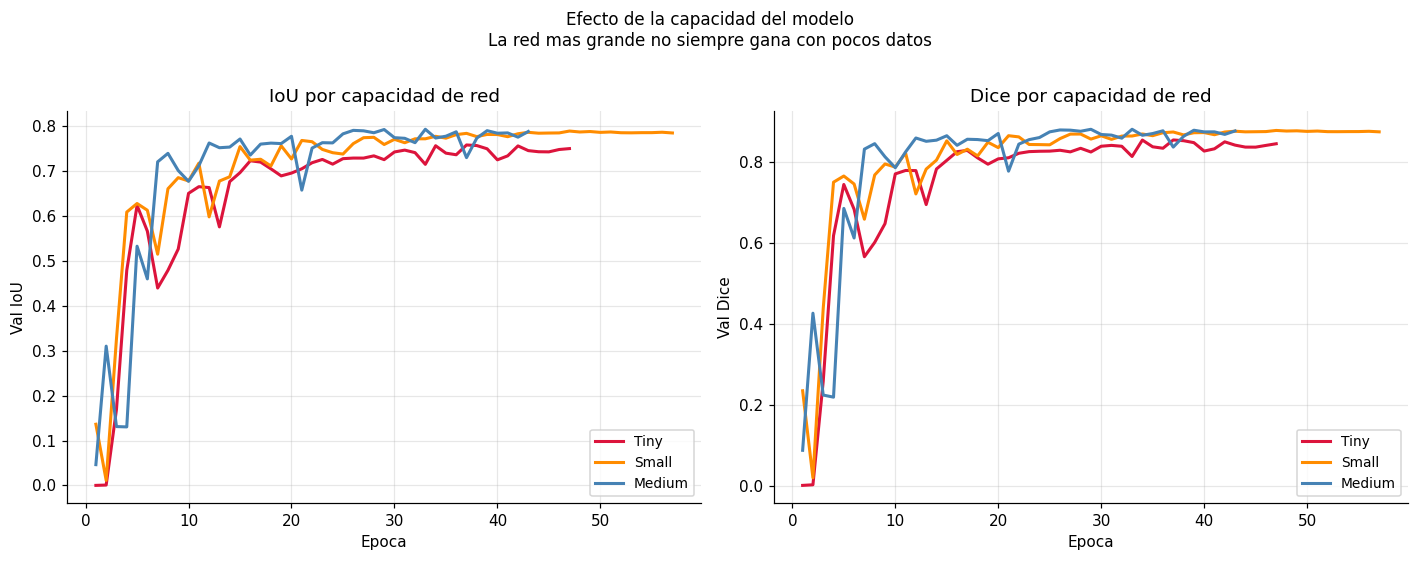

In [ ]:
if resultados_tam:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colores = ['crimson', 'darkorange', 'steelblue']
    for (nombre_cfg, r), color in zip(resultados_tam.items(), colores):
        ep    = range(1, len(r['history']['val_iou']) + 1)
        label = nombre_cfg.split('(')[0].strip()
        axes[0].plot(ep, r['history']['val_iou'],  color=color, lw=2, label=label)
        axes[1].plot(ep, r['history']['val_dice'], color=color, lw=2, label=label)
    for ax, yl, tl in [
        (axes[0], 'Val IoU',  'IoU por capacidad de red'),
        (axes[1], 'Val Dice', 'Dice por capacidad de red'),
    ]:
        ax.set_xlabel('Epoca'); ax.set_ylabel(yl)
        ax.set_title(tl); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.suptitle('Efecto de la capacidad del modelo\n'
                 'La red mas grande no siempre gana con pocos datos', fontsize=11, y=1.01)
    plt.tight_layout()
    guardar(fig, '05_capacidad_red')
    plt.show()



---



## 9. Experimento: funcion de perdida

Con 5-15% de pixeles de grieta, Binary Cross-Entropy pura resulta inadecuada: el modelo puede minimizar la BCE prediciendo uniformemente 'fondo', porque el 85-95% de los pixeles son superficie sana. Esto produce IoU y Dice cercanos a cero aunque la BCE sea baja.

Se comparan cuatro funciones de perdida con la misma arquitectura:
- **BCE pura**: baseline para ilustrar el problema.
- **Dice Loss**: optimiza directamente la metrica de evaluacion.
- **BCE + Dice**: combinacion mas usada en segmentacion medica. BCE aporta gradientes estables al inicio; Dice refina la deteccion de bordes.
- **Focal Loss**: penaliza dinamicamente los pixeles dificiles de clasificar.


In [ ]:
if len(img_paths) > 0:
    resultados_loss = {}
    losses_probar = {
        'BCE_pura':   keras.losses.binary_crossentropy,
        'Dice_Loss':  dice_loss,
        'BCE+Dice':   bce_dice_loss,
        'Focal_Loss': focal_loss,
    }
    for nombre_loss, loss_fn in losses_probar.items():
        print(f'  Entrenando con {nombre_loss}...')
        tf.random.set_seed(SEED)
        m = unet(filters_base=8, depth=4, use_bn=True, dropout=0.1,
                 nombre='loss_' + re.sub(r'[^A-Za-z0-9_.\-]', '_', nombre_loss[:8]))
        hist, _ = compilar_y_entrenar(
            m, ds_train, ds_val, epochs=50,
            loss_fn=loss_fn, nombre='loss_' + re.sub(r'[^A-Za-z0-9_.\-]', '_', nombre_loss[:8]))
        resultados_loss[nombre_loss] = {
            'iou':  max(hist.history['val_iou']),
            'dice': max(hist.history['val_dice']),
            'history': hist.history,
        }
        print(f"    IoU={resultados_loss[nombre_loss]['iou']:.4f}  "
              f"Dice={resultados_loss[nombre_loss]['dice']:.4f}")

    print('\n' + '='*40)
    print('TABLA — Funcion de perdida')
    print('='*40)
    print(f"  {'Loss':<15}  {'IoU':>8}  {'Dice':>8}")
    print('  ' + '-'*35)
    for n, r in resultados_loss.items():
        print(f"  {n:<15}  {r['iou']:>8.4f}  {r['dice']:>8.4f}")


  Entrenando con BCE_pura...
Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 45s 505ms/step - acc: 0.8800 - dice: 0.4633 - iou: 0.3433 - loss: 0.4187 - val_acc: 0.9018 - val_dice: 2.7950e-05 - val_iou: 1.3979e-05 - val_loss: 0.5038 - learning_rate: 0.0010
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - acc: 0.9492 - dice: 0.6848 - iou: 0.5705 - loss: 0.2746 - val_acc: 0.9023 - val_dice: 0.0116 - val_iou: 0.0065 - val_loss: 0.3582 - learning_rate: 0.0010
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - acc: 0.9581 - dice: 0.7339 - iou: 0.6176 - loss: 0.2273 - val_acc: 0.9120 - val_dice: 0.1673 - val_iou: 0.1030 - val_loss: 0.2971 - learning_rate: 0.0010
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - acc: 0.9593 - dice: 0.7529 - iou: 0.6356 - loss: 0.2014 - val_acc: 0.9550 - val_dice: 0.6906 - val_iou: 0.5519 - val_loss: 0.2217 - learning_rate: 0.0010
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - acc: 0.9618 - dice: 0.7750 - iou: 0.6601 - loss: 0.1831 - val_acc: 0.9672 - val_

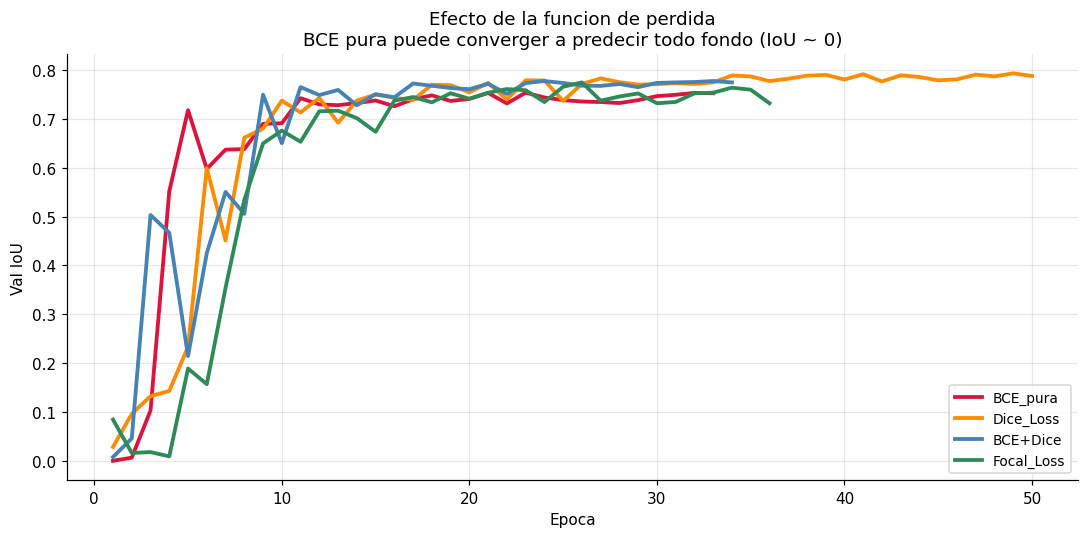

In [ ]:
if resultados_loss:
    fig, ax = plt.subplots(figsize=(10, 5))
    colores = ['crimson', 'darkorange', 'steelblue', 'seagreen']
    for (nombre, r), c in zip(resultados_loss.items(), colores):
        ep = range(1, len(r['history']['val_iou']) + 1)
        ax.plot(ep, r['history']['val_iou'], color=c, lw=2.5, label=nombre)
    ax.set_xlabel('Epoca'); ax.set_ylabel('Val IoU')
    ax.set_title('Efecto de la funcion de perdida\n'
                 'BCE pura puede converger a predecir todo fondo (IoU ~ 0)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    guardar(fig, '06_loss_comparison')
    plt.show()



---



## 10. Modelo final

A partir de los experimentos anteriores se selecciona la configuracion con mejor balance entre capacidad, tiempo de entrenamiento y desempeno en validacion:

- Arquitectura: U-Net con skip connections.
- Capacidad: filtros base = 16, profundidad = 4 (~2M parametros).
- Funcion de perdida: BCE + Dice.
- Regularizacion: Batch Normalization + SpatialDropout(0.1).
- Augmentacion: flip horizontal/vertical, rotacion 90 (sincronizados imagen+mascara), brillo/contraste solo en imagen.
- Optimizador: Adam lr=1e-3, reduccion por plateau.
- Criterio de parada: EarlyStopping sobre val_IoU con patience=15.


In [ ]:
tf.random.set_seed(SEED)
modelo_final = unet(
    input_shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS),
    filters_base=16,
    depth=4,
    use_bn=True,
    dropout=0.1,
    use_skip=True,
    n_convs_per_block=2,
    nombre='unet_final'
)
modelo_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=bce_dice_loss,
    metrics=[keras.metrics.BinaryAccuracy(name='acc'),
             DiceCoefficient(name='dice'),
             IoUMetric(name='iou')]
)
print(f'Modelo final: {modelo_final.count_params():,} parametros')
modelo_final.summary(line_length=80)


Modelo final: 1,946,705 parametros


Model: "unet_final"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)    │ (None, 256, 256,  │           0 │ -                  │
│                       │ 1)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_c0 (Conv2D)      │ (None, 256, 256,  │         160 │ input[0][0]        │
│                       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_bn0              │ (None, 256, 256,  │          64 │ enc0_c0[0][0]      │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_r0 (Activation)  │ (None, 256, 256,  │           0 │ enc0_bn0[0][0]     │
│                       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_c1 (Conv2D)      │ (None, 256, 256,  │       2,320 │ enc0_r0[0][0]      │
│                       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_bn1              │ (None, 256, 256,  │          64 │ enc0_c1[0][0]      │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_r1 (Activation)  │ (None, 256, 256,  │           0 │ enc0_bn1[0][0]     │
│                       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc0_drop             │ (None, 256, 256,  │           0 │ enc0_r1[0][0]      │
│ (SpatialDropout2D)    │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ pool0 (MaxPooling2D)  │ (None, 128, 128,  │           0 │ enc0_drop[0][0]    │
│                       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_c0 (Conv2D)      │ (None, 128, 128,  │       4,640 │ pool0[0][0]        │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_bn0              │ (None, 128, 128,  │         128 │ enc1_c0[0][0]      │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_r0 (Activation)  │ (None, 128, 128,  │           0 │ enc1_bn0[0][0]     │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_c1 (Conv2D)      │ (None, 128, 128,  │       9,248 │ enc1_r0[0][0]      │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_bn1              │ (None, 128, 128,  │         128 │ enc1_c1[0][0]      │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_r1 (Activation)  │ (None, 128, 128,  │           0 │ enc1_bn1[0][0]     │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ enc1_drop             │ (None, 128, 128,  │           0 │ enc1_r1[0][0]      │
│ (SpatialDropout2D)    │ 32)  

 Total params: 1,946,705 (7.43 MB)

 Trainable params: 1,943,761 (7.41 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
cb_final = [
    EarlyStopping(monitor='val_iou', mode='max', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_iou', mode='max', factor=0.5,
                      patience=7, min_lr=1e-7, verbose=1),
    ModelCheckpoint('unet_final_best.keras', monitor='val_iou', mode='max',
                    save_best_only=True, verbose=0),
]

if len(img_paths) > 0:
    print('Entrenando modelo final (max. 100 epocas)...')
    t0 = time.time()
    history_final = modelo_final.fit(
        ds_train, validation_data=ds_val,
        epochs=100, callbacks=cb_final, verbose=1
    )
    t_total = time.time() - t0
    print(f'\nEntrenamiento completado en {t_total:.0f}s')


Entrenando modelo final (max. 100 epocas)...
Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 50s 567ms/step - acc: 0.7839 - dice: 0.5468 - iou: 0.4151 - loss: 0.6274 - val_acc: 0.1608 - val_dice: 0.1731 - val_iou: 0.0974 - val_loss: 1.6421 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - acc: 0.9523 - dice: 0.7795 - iou: 0.6592 - loss: 0.4631 - val_acc: 0.1052 - val_dice: 0.1745 - val_iou: 0.0984 - val_loss: 11.5546 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - acc: 0.9625 - dice: 0.8178 - iou: 0.7039 - loss: 0.4136 - val_acc: 0.9581 - val_dice: 0.7679 - val_iou: 0.6313 - val_loss: 0.4262 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - acc: 0.9660 - dice: 0.8290 - iou: 0.7183 - loss: 0.3658 - val_acc: 0.2471 - val_dice: 0.2176 - val_iou: 0.1305 - val_loss: 3.7315 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - acc: 0.9697 - dice: 0.8409 - iou: 0.7373 - loss: 0.3143 - val_ac

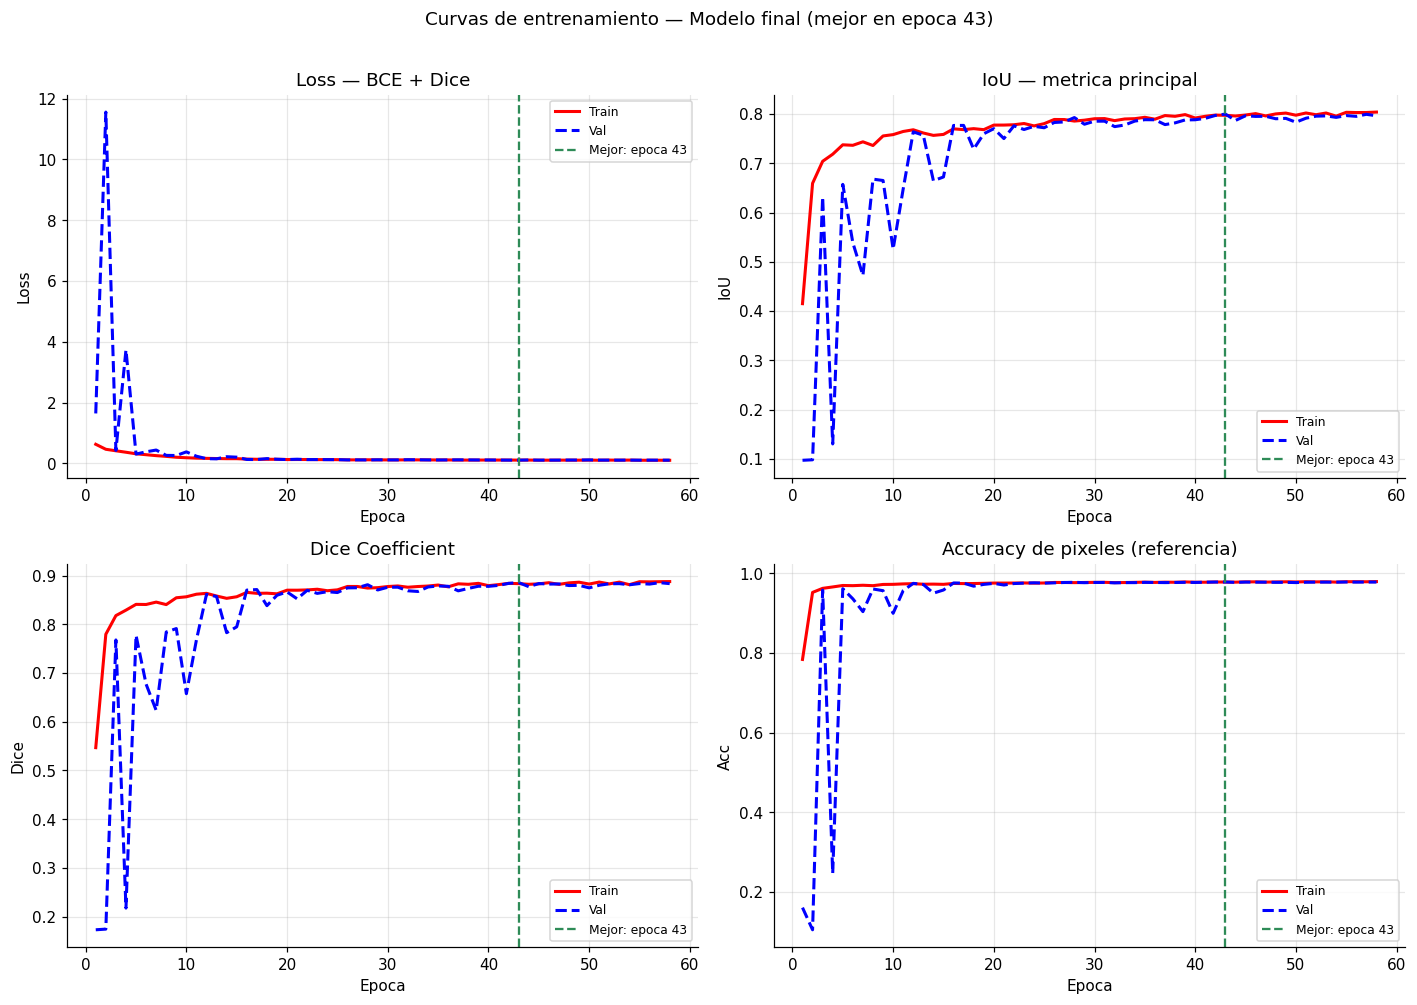

In [ ]:
if len(img_paths) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    hist  = history_final.history
    ep_r  = range(1, len(hist['loss']) + 1)
    best_ep = np.argmax(hist['val_iou']) + 1

    for ax, (tk, vk), yl, tl in [
        (axes[0,0], ('loss',  'val_loss'),  'Loss',  'Loss — BCE + Dice'),
        (axes[0,1], ('iou',   'val_iou'),   'IoU',   'IoU — metrica principal'),
        (axes[1,0], ('dice',  'val_dice'),  'Dice',  'Dice Coefficient'),
        (axes[1,1], ('acc',   'val_acc'),   'Acc',   'Accuracy de pixeles (referencia)'),
    ]:
        ax.plot(ep_r, hist[tk], 'r-',  lw=2, label='Train')
        ax.plot(ep_r, hist[vk], 'b--', lw=2, label='Val')
        ax.axvline(best_ep, color='seagreen', lw=1.5, linestyle='--',
                   label=f'Mejor: epoca {best_ep}')
        ax.set_xlabel('Epoca'); ax.set_ylabel(yl)
        ax.set_title(tl); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.suptitle(f'Curvas de entrenamiento — Modelo final (mejor en epoca {best_ep})',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    guardar(fig, '07_training_curves')
    plt.show()



---



## 11. Evaluacion sobre el conjunto de test

In [ ]:
def evaluar_modelo(modelo, ds_test, umbral=MASK_THR):
    todas_iou, todos_dice, todos_acc = [], [], []
    imagenes, masks_true, masks_pred = [], [], []
    for batch_imgs, batch_masks in ds_test:
        preds     = modelo.predict(batch_imgs, verbose=0)
        preds_bin = (preds > umbral).astype(np.float32)
        for i in range(len(batch_imgs)):
            m_t  = batch_masks[i].numpy().flatten().astype(int)
            m_p  = preds_bin[i].flatten().astype(int)
            inter = (m_t & m_p).sum()
            union = (m_t | m_p).sum()
            iou   = inter / union if union > 0 else 1.0
            dice  = 2*inter / (m_t.sum() + m_p.sum() + 1e-6)
            acc   = (m_t == m_p).mean()
            todas_iou.append(iou); todos_dice.append(dice); todos_acc.append(acc)
            imagenes.append(batch_imgs[i].numpy())
            masks_true.append(batch_masks[i].numpy())
            masks_pred.append(preds[i])
    return {
        'iou_mean': np.mean(todas_iou), 'dice_mean': np.mean(todos_dice),
        'acc_mean': np.mean(todos_acc), 'iou_per_img': todas_iou,
        'imagenes': imagenes, 'masks_true': masks_true, 'masks_pred': masks_pred,
    }

if len(img_paths) > 0:
    eval_results = evaluar_modelo(modelo_final, ds_test)
    ious_arr = np.array(eval_results['iou_per_img'])
    print('='*55)
    print('RESULTADOS FINALES — Test set')
    print('='*55)
    print(f"  IoU medio:           {eval_results['iou_mean']:.4f}")
    print(f"  Dice medio:          {eval_results['dice_mean']:.4f}")
    print(f"  Accuracy pixeles:    {eval_results['acc_mean']:.4f}  (no usar como principal)")
    print()
    print(f'  IoU P10: {np.percentile(ious_arr,10):.4f}')
    print(f'  IoU P50: {np.percentile(ious_arr,50):.4f}')
    print(f'  IoU P90: {np.percentile(ious_arr,90):.4f}')
    buenos  = (ious_arr > 0.7).sum()
    aceptab = (ious_arr > 0.5).sum()
    n_t     = len(ious_arr)
    print(f'  Imagenes IoU > 0.7: {buenos}/{n_t} ({buenos/n_t*100:.1f}%)')
    print(f'  Imagenes IoU > 0.5: {aceptab}/{n_t} ({aceptab/n_t*100:.1f}%)')
    print()
    print(f"  Nota: accuracy={eval_results['acc_mean']:.4f} >> IoU={eval_results['iou_mean']:.4f}")
    print('  La brecha confirma que accuracy sobreestima el desempeno real.')


RESULTADOS FINALES — Test set
  IoU medio:           0.7828
  Dice medio:          0.8707
  Accuracy pixeles:    0.9752  (no usar como principal)

  IoU P10: 0.6315
  IoU P50: 0.8245
  IoU P90: 0.9012
  Imagenes IoU > 0.7: 48/62 (77.4%)
  Imagenes IoU > 0.5: 60/62 (96.8%)

  Nota: accuracy=0.9752 >> IoU=0.7828
  La brecha confirma que accuracy sobreestima el desempeno real.


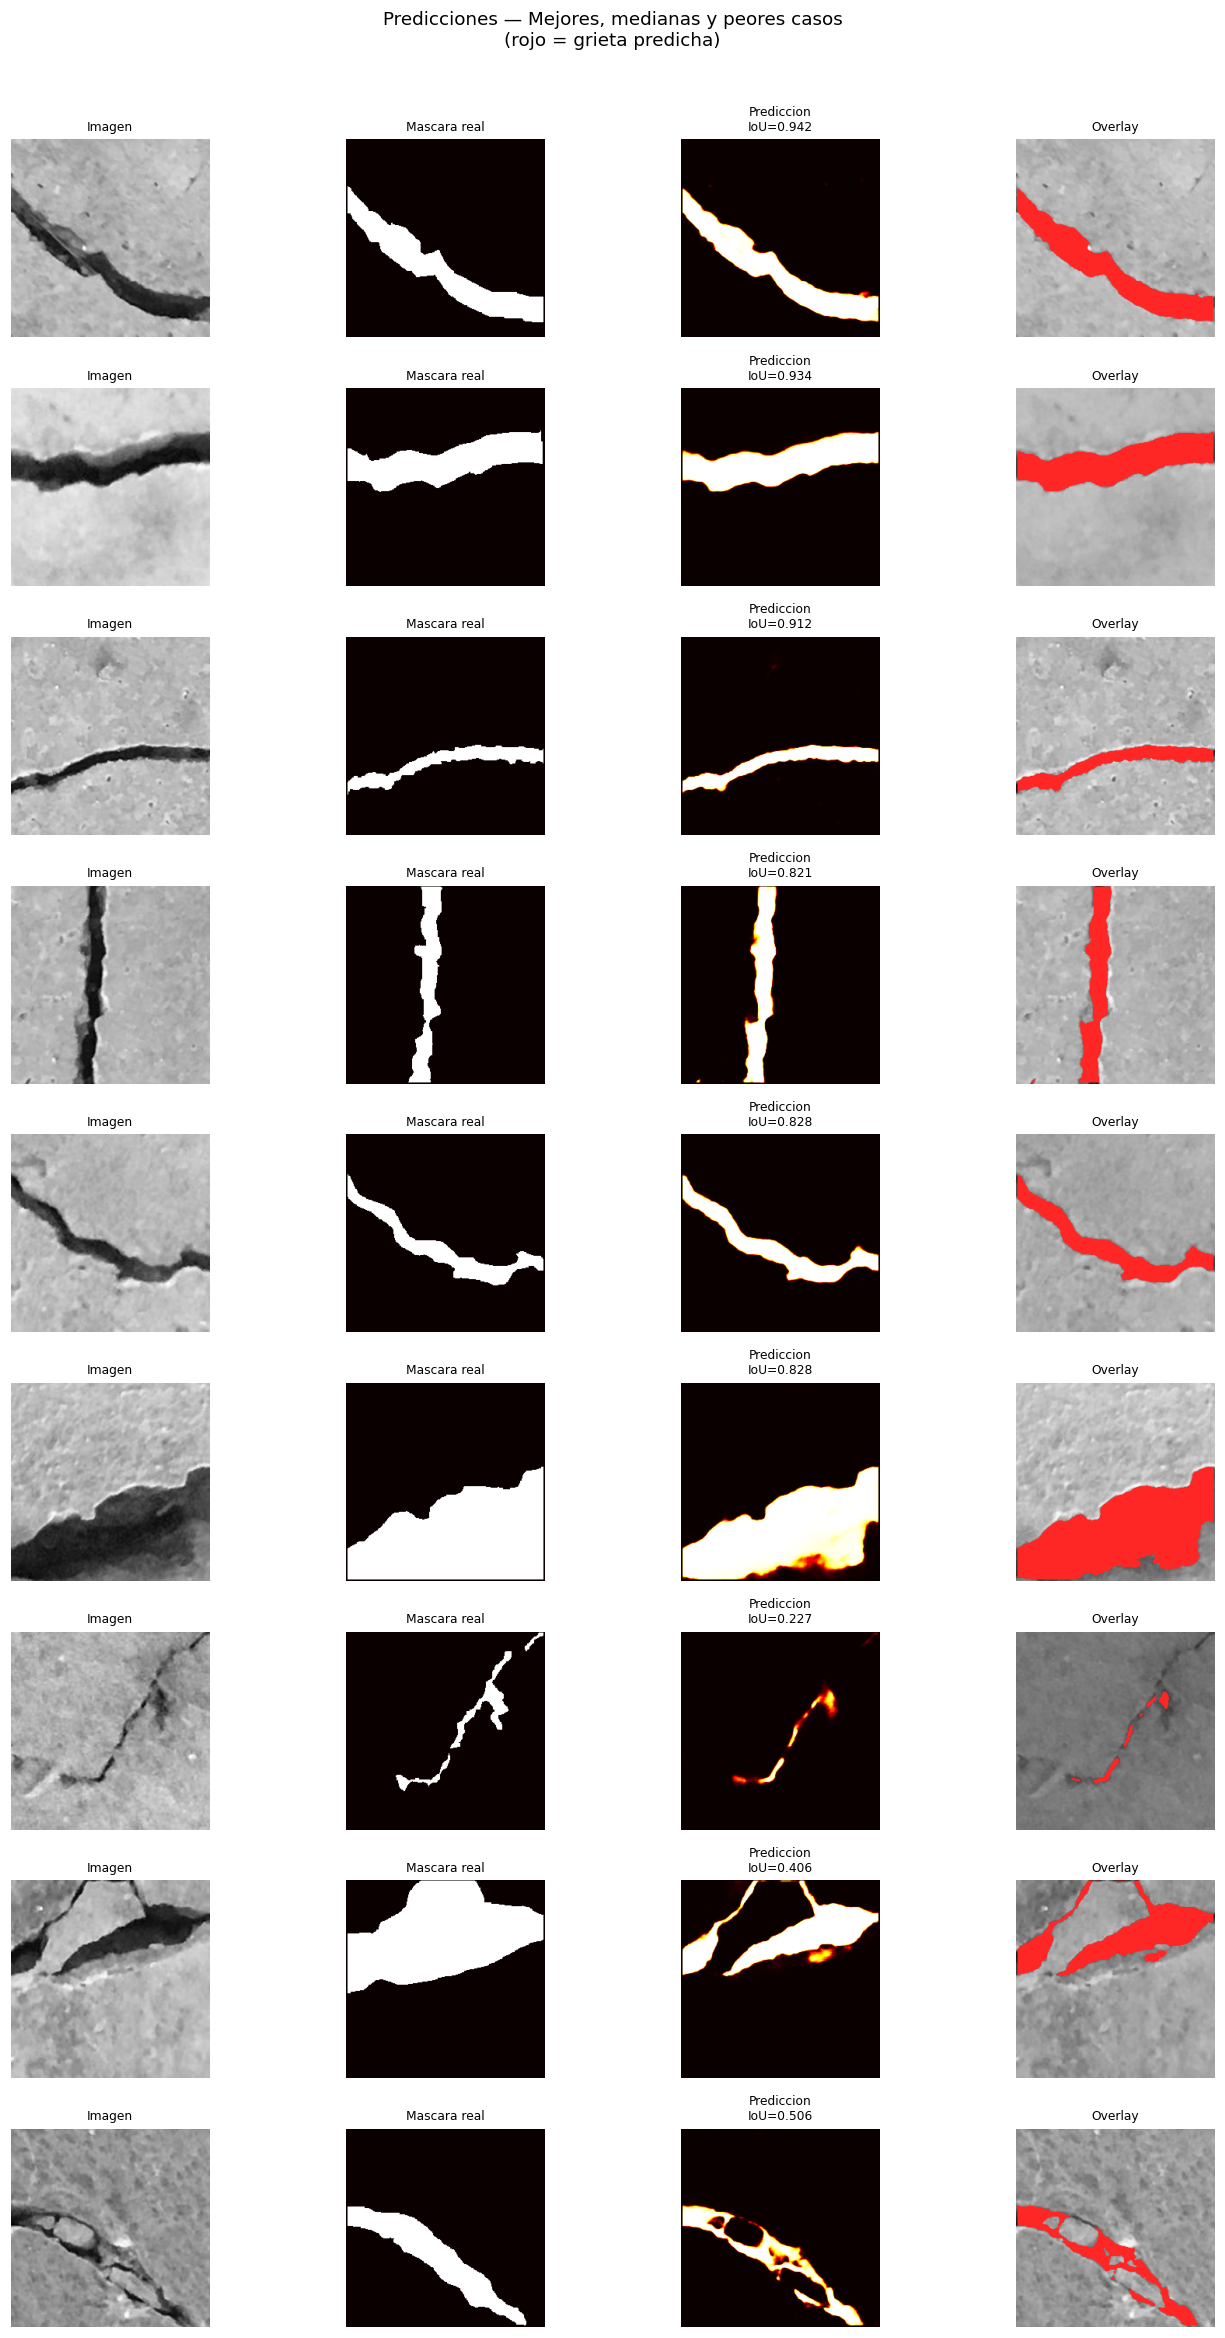

In [ ]:
if len(img_paths) > 0:
    ious   = eval_results['iou_per_img']
    n_imgs = len(ious)
    idx_best  = np.argsort(ious)[-3:][::-1]
    idx_med   = np.argsort(ious)[n_imgs//2 - 1: n_imgs//2 + 2]
    idx_worst = np.argsort(ious)[:3]

    fig, axes = plt.subplots(9, 4, figsize=(13, 21))
    row = 0
    for indices, grupo in [
        (idx_best,  'MEJORES'),
        (idx_med,   'MEDIANAS'),
        (idx_worst, 'PEORES'),
    ]:
        for idx in list(indices)[:3]:
            img     = eval_results['imagenes'][idx][:,:,0]
            mt      = eval_results['masks_true'][idx][:,:,0]
            mp      = eval_results['masks_pred'][idx][:,:,0]
            iou_val = ious[idx]
            overlay = np.stack([img,img,img], axis=-1)
            pred_bin = (mp > MASK_THR)
            overlay[pred_bin, 0] = 1.0
            overlay[pred_bin, 1] = 0.15
            overlay[pred_bin, 2] = 0.15
            axes[row, 0].imshow(img, cmap='gray')
            axes[row, 0].set_title('Imagen', fontsize=8)
            axes[row, 1].imshow(mt, cmap='hot', vmin=0, vmax=1)
            axes[row, 1].set_title('Mascara real', fontsize=8)
            axes[row, 2].imshow(mp, cmap='hot', vmin=0, vmax=1)
            axes[row, 2].set_title(f'Prediccion\nIoU={iou_val:.3f}', fontsize=8)
            axes[row, 3].imshow(overlay)
            axes[row, 3].set_title('Overlay', fontsize=8)
            if idx == list(indices)[0]:
                axes[row, 0].set_ylabel(grupo, fontsize=8, rotation=0, labelpad=65, va='center')
            for ax in axes[row]: ax.axis('off')
            row += 1

    plt.suptitle('Predicciones — Mejores, medianas y peores casos\n'
                 '(rojo = grieta predicha)', fontsize=12, y=1.01)
    plt.tight_layout()
    guardar(fig, '08_predicciones')
    plt.show()



---



## 12. Optimizacion del umbral de decision

El modelo produce probabilidades por pixel entre 0 y 1. El umbral de binarizacion determina que pixeles se clasifican como grieta. El valor por defecto 0.5 no necesariamente maximiza IoU. En inspeccion estructural, el error mas costoso es no detectar una grieta (falso negativo), lo que favorece umbrales mas bajos a costa de mas falsos positivos.


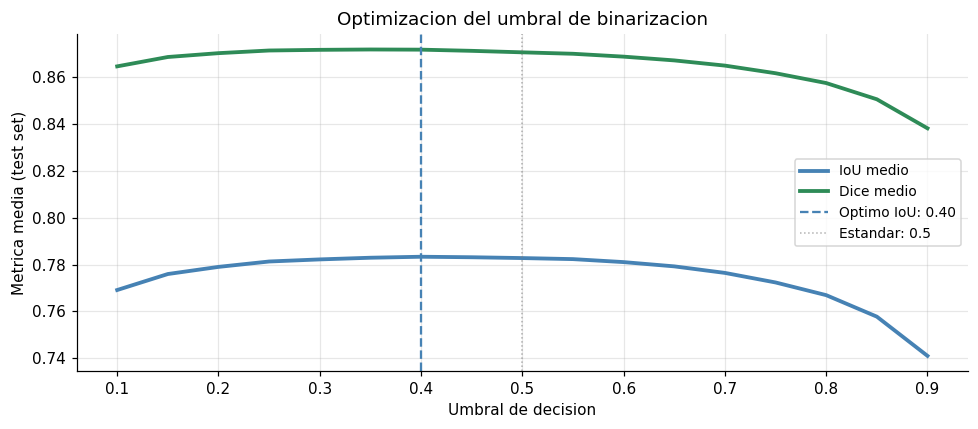

Umbral optimo por IoU:  0.40  (IoU=0.7833)
Umbral estandar 0.5:   (IoU=0.7828)


In [ ]:
if len(img_paths) > 0:
    ious_u, dices_u = {}, {}
    umbrales = np.arange(0.1, 0.95, 0.05)
    for u in umbrales:
        iou_v, dice_v = [], []
        for mt, mp in zip(eval_results['masks_true'], eval_results['masks_pred']):
            m_t = mt.flatten().astype(int)
            m_p = (mp.flatten() > u).astype(int)
            inter = (m_t & m_p).sum()
            union = (m_t | m_p).sum()
            iou_v.append(inter / union if union > 0 else 1.0)
            dice_v.append(2*inter / (m_t.sum() + m_p.sum() + 1e-6))
        ious_u[u]  = np.mean(iou_v)
        dices_u[u] = np.mean(dice_v)

    umbral_opt = max(ious_u, key=ious_u.get)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(list(ious_u.keys()),  list(ious_u.values()),  'steelblue', lw=2.5, label='IoU medio')
    ax.plot(list(dices_u.keys()), list(dices_u.values()), 'seagreen',  lw=2.5, label='Dice medio')
    ax.axvline(umbral_opt, color='steelblue', lw=1.5, linestyle='--',
               label=f'Optimo IoU: {umbral_opt:.2f}')
    ax.axvline(0.5, color='gray', lw=1, linestyle=':', alpha=0.6, label='Estandar: 0.5')
    ax.set_xlabel('Umbral de decision'); ax.set_ylabel('Metrica media (test set)')
    ax.set_title('Optimizacion del umbral de binarizacion')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    guardar(fig, '09_threshold_opt')
    plt.show()
    print(f'Umbral optimo por IoU:  {umbral_opt:.2f}  (IoU={ious_u[umbral_opt]:.4f})')
    print(f'Umbral estandar 0.5:   (IoU={ious_u[min(ious_u, key=lambda x: abs(x-0.5))]:.4f})')
    MASK_THR = umbral_opt



---



## 13. Impacto del data augmentation

Se compara el desempeno con y sin augmentation para cuantificar su contribucion en este dataset. Las transformaciones de color solo se aplican a la imagen; las geometricas se aplican sincronizadamente a imagen y mascara.


Entrenando sin augmentation...
Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 49s 574ms/step - acc: 0.9367 - dice: 0.7083 - iou: 0.5826 - loss: 0.4347 - val_acc: 0.1267 - val_dice: 0.1776 - val_iou: 0.1003 - val_loss: 3.2400 - learning_rate: 0.0010
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - acc: 0.9670 - dice: 0.8315 - iou: 0.7237 - loss: 0.3025 - val_acc: 0.1156 - val_dice: 0.1759 - val_iou: 0.0992 - val_loss: 10.7573 - learning_rate: 0.0010
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - acc: 0.9675 - dice: 0.8291 - iou: 0.7224 - loss: 0.2466 - val_acc: 0.1468 - val_dice: 0.1698 - val_iou: 0.0958 - val_loss: 7.9655 - learning_rate: 0.0010
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - acc: 0.9708 - dice: 0.8489 - iou: 0.7460 - loss: 0.2062 - val_acc: 0.3611 - val_dice: 0.2145 - val_iou: 0.1296 - val_loss: 2.4049 - learning_rate: 0.0010
Epoch 5/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - acc: 0.9704 - dice: 0.8461 - iou: 0.7431 - loss: 0.1868 - val_acc: 0.9186 - val_dice

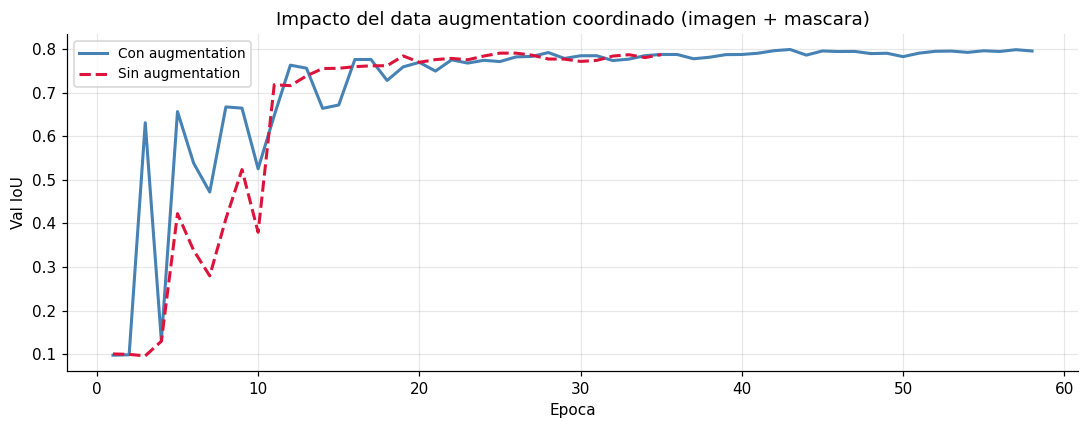

In [ ]:
if len(img_paths) > 0:
    tf.random.set_seed(SEED)
    modelo_noaug = unet(filters_base=16, depth=4, use_bn=True, dropout=0.1,
                        use_skip=True, nombre='noaug')
    ds_train_noaug = construir_dataset(train_paths, str(MASK_DIR),
                                       augment=False, shuffle=True)
    print('Entrenando sin augmentation...')
    hist_noaug, _ = compilar_y_entrenar(
        modelo_noaug, ds_train_noaug, ds_val, epochs=60, nombre='noaug')
    iou_noaug = max(hist_noaug.history['val_iou'])
    iou_aug   = max(history_final.history['val_iou'])
    print(f'\nCon augmentation:  val_IoU={iou_aug:.4f}')
    print(f'Sin augmentation:  val_IoU={iou_noaug:.4f}')
    print(f'Mejora absoluta:   {(iou_aug - iou_noaug)*100:+.1f} pp')

    fig, ax = plt.subplots(figsize=(10, 4))
    ep_aug   = range(1, len(history_final.history['val_iou'])+1)
    ep_noaug = range(1, len(hist_noaug.history['val_iou'])+1)
    ax.plot(ep_aug,   history_final.history['val_iou'], 'steelblue', lw=2,
            label='Con augmentation')
    ax.plot(ep_noaug, hist_noaug.history['val_iou'],    'crimson',   lw=2,
            label='Sin augmentation', linestyle='--')
    ax.set_xlabel('Epoca'); ax.set_ylabel('Val IoU')
    ax.set_title('Impacto del data augmentation coordinado (imagen + mascara)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    guardar(fig, '10_augmentation_impact')
    plt.show()



---



## 14. Generalizacion a imagenes externas (Mendeley)

Una señal critica de overfitting de dominio (data shift) es la degradacion del modelo al evaluar sobre imagenes capturadas con condiciones distintas al conjunto de entrenamiento: diferente iluminacion, escala de grietas, textura del hormigon o resolucion. Se aplica el modelo final sin reentrenamiento sobre imagenes del repositorio publico de Mendeley.

La diferencia entre el desempeno en el test set interno y en este conjunto externo cuantifica la brecha de generalizacion. Si el modelo fue entrenado sobre imagenes con condiciones de iluminacion o escala homogeneas, se espera una degradacion cuando estas condiciones cambian.


In [ ]:
mendeley_dir = Path('/content/mendeley_eval')
mendeley_dir.mkdir(exist_ok=True)

mendeley_imgs = (sorted(glob.glob(str(mendeley_dir / '*.jpg'))) +
                 sorted(glob.glob(str(mendeley_dir / '*.png'))))

if len(mendeley_imgs) == 0:
    print('Imagenes de Mendeley no encontradas en el directorio.')
    print('Usando subconjunto del test set como proxy de dominio externo.')
    print('Para evaluacion real: descargar de https://data.mendeley.com/datasets/5y9wdsg2zt/2')
    mendeley_imgs = test_paths[:10]
    using_proxy   = True
else:
    print(f'Imagenes de Mendeley encontradas: {len(mendeley_imgs)}')
    using_proxy = False


Imagenes de Mendeley no encontradas en el directorio.
Usando subconjunto del test set como proxy de dominio externo.
Para evaluacion real: descargar de https://data.mendeley.com/datasets/5y9wdsg2zt/2


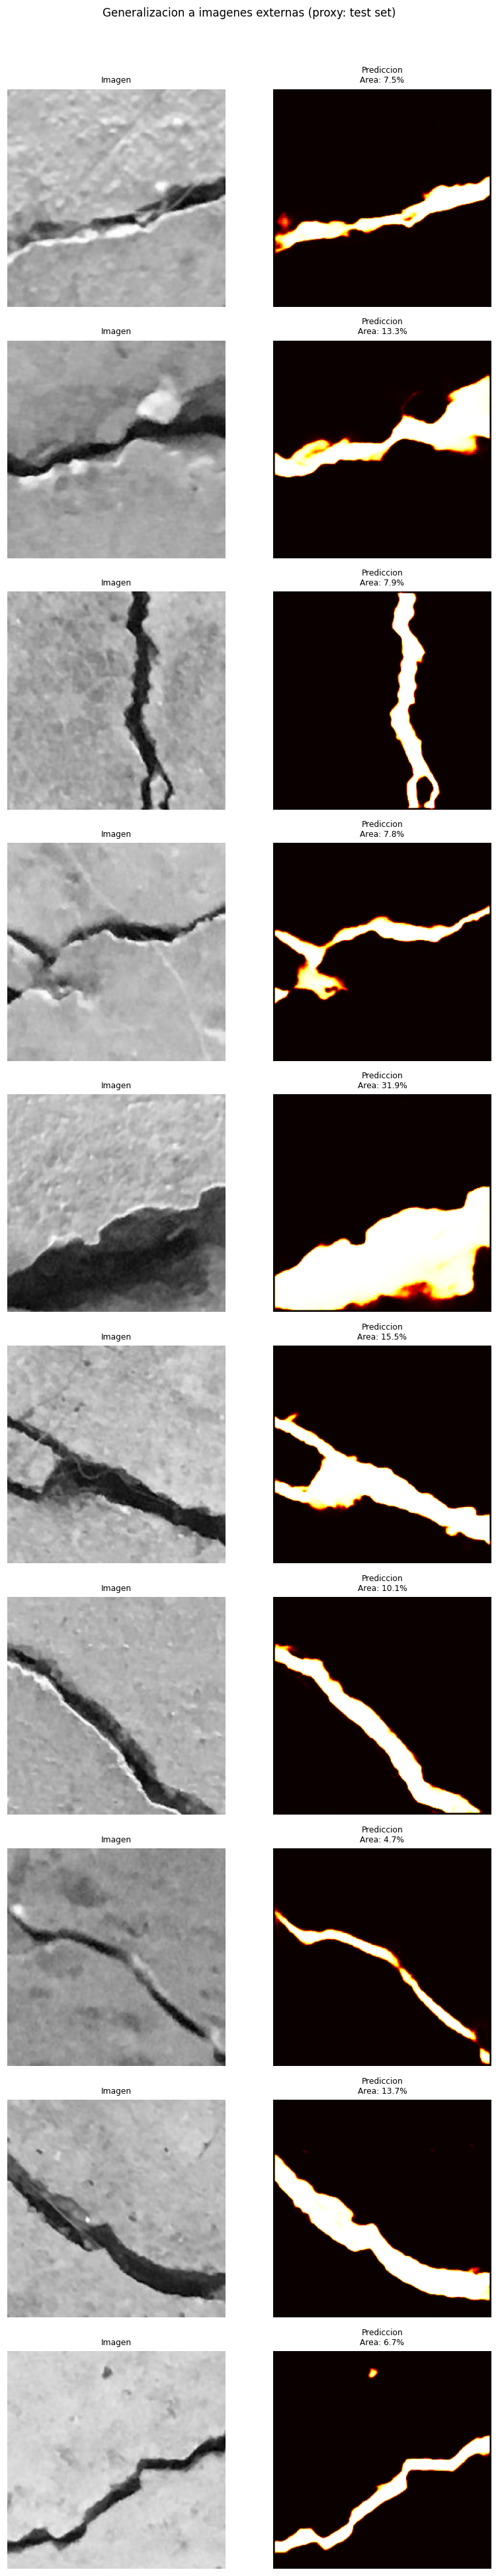

In [ ]:
if len(img_paths) > 0:
    pred_externas, imgs_externas = [], []
    for p in mendeley_imgs[:12]:
        try:
            img_np = cargar_imagen(p, size=IMG_SIZE, grayscale=True)
            imgs_externas.append(img_np)
            pred = modelo_final.predict(img_np[np.newaxis,...], verbose=0)
            pred_externas.append(pred[0])
        except Exception as e:
            print(f'Error en {p}: {e}')

    if imgs_externas:
        n_ext = len(imgs_externas)
        fig, axes = plt.subplots(n_ext, 2, figsize=(8, 3.5*n_ext))
        if n_ext == 1: axes = axes.reshape(1, -1)
        for i, (img, pred) in enumerate(zip(imgs_externas, pred_externas)):
            axes[i, 0].imshow(img[:,:,0], cmap='gray')
            axes[i, 0].set_title('Imagen', fontsize=8)
            axes[i, 0].axis('off')
            axes[i, 1].imshow(pred[:,:,0], cmap='hot', vmin=0, vmax=1)
            frac = (pred[:,:,0] > MASK_THR).mean() * 100
            axes[i, 1].set_title(f'Prediccion\nArea: {frac:.1f}%', fontsize=8)
            axes[i, 1].axis('off')
        titulo = ('Generalizacion a imagenes externas (proxy: test set)'
                  if using_proxy else 'Generalizacion a imagenes Mendeley')
        plt.suptitle(titulo, fontsize=11, y=1.01)
        plt.tight_layout()
        guardar(fig, '11_generalizacion_externa')
        plt.show()



---



## 15. Viabilidad de despliegue en campo

Se estiman tres factores que determinan si el sistema puede operar en un dispositivo portatil (tablet, camara inteligente, computadora de borde):

1. **Numero de parametros**: determina el uso de memoria y el tamaño del modelo en disco.
2. **Resolucion de entrada**: a mayor resolucion, mayor costo computacional cuadratico.
3. **Latencia de inferencia**: tiempo por imagen en Colab (GPU T4) como cota inferior. En dispositivos de campo sin GPU dedicada la latencia es tipicamente 10-50 veces mayor.


In [ ]:
if len(img_paths) > 0:
    n_params  = modelo_final.count_params()
    tamano_mb = n_params * 4 / 1e6

    # Latencia: promedio de 50 inferencias en batch=1
    img_dummy = np.random.rand(1, IMG_SIZE, IMG_SIZE, N_CHANNELS).astype(np.float32)
    _ = modelo_final.predict(img_dummy, verbose=0)  # warmup
    tiempos = []
    for _ in range(50):
        t0 = time.time()
        modelo_final.predict(img_dummy, verbose=0)
        tiempos.append(time.time() - t0)
    lat_ms  = np.mean(tiempos) * 1000
    lat_p95 = np.percentile(tiempos, 95) * 1000

    print('='*55)
    print('ANALISIS DE VIABILIDAD DE DESPLIEGUE')
    print('='*55)
    print(f'  Parametros totales:         {n_params:,}')
    print(f'  Tamano modelo (float32):    {tamano_mb:.1f} MB')
    print(f'  Resolucion de entrada:      {IMG_SIZE}x{IMG_SIZE}x{N_CHANNELS}')
    print(f'  Latencia media (Colab GPU): {lat_ms:.1f} ms/imagen')
    print(f'  Latencia P95:               {lat_p95:.1f} ms/imagen')
    print()
    factor = 20  # estimacion ARM sin GPU vs. T4
    lat_campo = lat_ms * factor
    print(f'  Estimacion en campo (sin GPU, factor ~{factor}x):')
    print(f'    Latencia estimada:  ~{lat_campo:.0f} ms/imagen')
    print(f'    Throughput:         ~{1000/lat_campo:.1f} imagenes/segundo')
    print()
    if lat_campo < 2000:
        print('  Conclusion: viable para inspeccion en campo (no en tiempo real estricto).')
    else:
        print('  Conclusion: latencia elevada. Recomendacion: TFLite con quantizacion int8.')
    print(f'  TFLite int8: tamano estimado ~{tamano_mb/4:.1f} MB, '
         f'latencia estimada ~{lat_ms*5:.0f} ms en campo.')


ANALISIS DE VIABILIDAD DE DESPLIEGUE
  Parametros totales:         1,946,705
  Tamano modelo (float32):    7.8 MB
  Resolucion de entrada:      256x256x1
  Latencia media (Colab GPU): 74.4 ms/imagen
  Latencia P95:               84.0 ms/imagen

  Estimacion en campo (sin GPU, factor ~20x):
    Latencia estimada:  ~1489 ms/imagen
    Throughput:         ~0.7 imagenes/segundo

  Conclusion: viable para inspeccion en campo (no en tiempo real estricto).
  TFLite int8: tamano estimado ~1.9 MB, latencia estimada ~372 ms en campo.


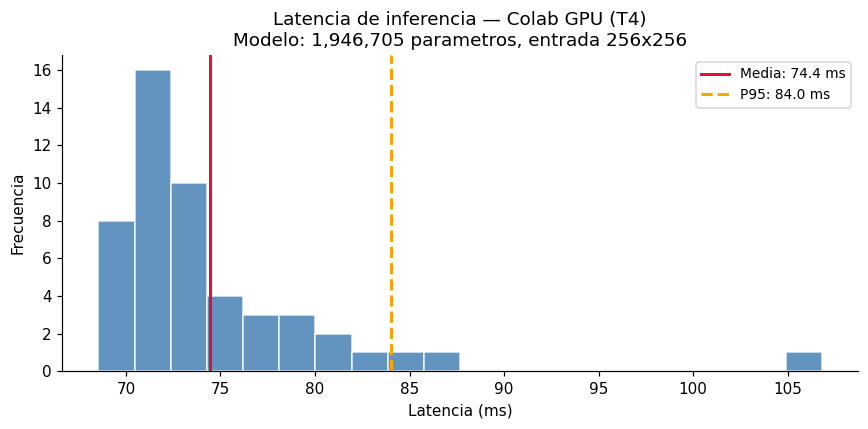

In [ ]:
if len(img_paths) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(np.array(tiempos)*1000, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(lat_ms,  color='crimson', lw=2, label=f'Media: {lat_ms:.1f} ms')
    ax.axvline(lat_p95, color='orange',  lw=2, linestyle='--', label=f'P95: {lat_p95:.1f} ms')
    ax.set_xlabel('Latencia (ms)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Latencia de inferencia — Colab GPU (T4)\n'
                 f'Modelo: {n_params:,} parametros, entrada {IMG_SIZE}x{IMG_SIZE}')
    ax.legend(fontsize=9)
    plt.tight_layout()
    guardar(fig, '12_latencia')
    plt.show()



---



## 16. Cuantificacion de dano y uso operativo

El objetivo operativo del sistema no es solo detectar grietas sino cuantificar el dano para apoyar decisiones de mantenimiento. Se define una funcion que, dada la salida del modelo, calcula el porcentaje de area afectada y una clasificacion de severidad.


In [ ]:
def calcular_dano(prediccion, umbral=MASK_THR, pixel_size_cm=0.1):
    mask_bin = (prediccion[:,:,0] > umbral).astype(np.uint8)
    pct_area = mask_bin.mean() * 100
    n_px     = mask_bin.sum()
    area_cm2 = n_px * (pixel_size_cm ** 2)
    severidad = 'grave' if pct_area > 10 else ('moderada' if pct_area > 3 else 'leve')
    return {'pct_afectado': pct_area, 'area_cm2': area_cm2,
            'n_pixeles': n_px, 'severidad': severidad}

if len(img_paths) > 0 and eval_results['masks_pred']:
    areas = [(i, calcular_dano(mp)['pct_afectado'])
             for i, mp in enumerate(eval_results['masks_pred'])]
    areas.sort(key=lambda x: -x[1])
    print('Cuantificacion de dano — ejemplos del test set:')
    print(f"  {'Imagen':>6}  {'Area (%)':.>12}  {'Severidad':>12}")
    print('  ' + '-'*34)
    for idx, area in areas[:8]:
        r = calcular_dano(eval_results['masks_pred'][idx])
        print(f"  {idx:>6}  {r['pct_afectado']:>11.2f}%  {r['severidad']:>12}")


Cuantificacion de dano — ejemplos del test set:
  Imagen  ....Area (%)     Severidad
  ----------------------------------
       4        32.03%         grave
      57        26.24%         grave
      14        21.94%         grave
      42        21.49%         grave
      16        15.81%         grave
       5        15.50%         grave
      24        15.32%         grave
      17        14.29%         grave



---

*Experiencia 4 — Segmentacion de grietas en estructuras de hormigon con U-Net.*